In [3]:
import pandas as pd
import numpy as np
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# load fresh
df_train = pd.read_csv("fraudTrain.csv")
df_test  = pd.read_csv("fraudTest.csv")
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

# extract hour (most important time feature)
df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_test['trans_date_trans_time']  = pd.to_datetime(df_test['trans_date_trans_time'])

df_train['hour'] = df_train['trans_date_trans_time'].dt.hour
df_test['hour']  = df_test['trans_date_trans_time'].dt.hour

# target encode ONLY category and merchant (the winning features)
cat_cols = ['merchant', 'category']
te = TargetEncoder(cols=cat_cols, smoothing=0.3)
df_train[cat_cols] = te.fit_transform(df_train[cat_cols], df_train['is_fraud'])
df_test[cat_cols]  = te.transform(df_test[cat_cols])

# keep ONLY the 4 winning features
final_features = ['amt', 'hour', 'category', 'merchant']

X_train = df_train[final_features]
y_train = df_train['is_fraud']
X_test  = df_test[final_features]
y_test  = df_test['is_fraud']

print("Final features:", final_features)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Final features: ['amt', 'hour', 'category', 'merchant']
Train shape: (1296675, 4)
Test shape: (555719, 4)


In [4]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=50,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'
)
model.fit(X_train, y_train)
print("Final model trained!")

Final model trained!


Final Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    553574
       Fraud       0.20      0.93      0.33      2145

    accuracy                           0.99    555719
   macro avg       0.60      0.96      0.66    555719
weighted avg       1.00      0.99      0.99    555719



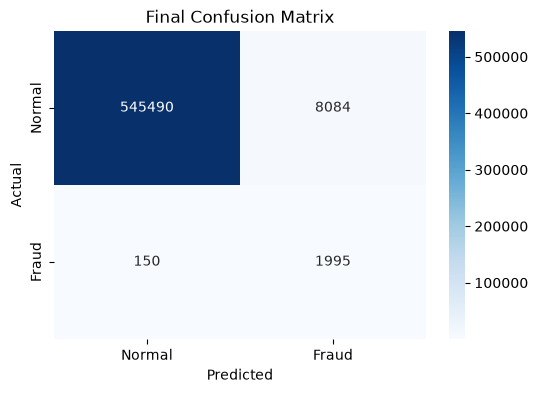

In [5]:
y_pred = model.predict(X_test)

print("Final Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal','Fraud']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'],
            cmap='Blues')
plt.title("Final Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [6]:
from sklearn.metrics import precision_recall_curve

y_proba = model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]

y_pred_tuned = (y_proba >= best_threshold).astype(int)

print("Best threshold:", round(best_threshold, 3))
print(classification_report(y_test, y_pred_tuned, target_names=['Normal','Fraud']))

Best threshold: 0.959
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    553574
       Fraud       0.77      0.65      0.70      2145

    accuracy                           1.00    555719
   macro avg       0.88      0.82      0.85    555719
weighted avg       1.00      1.00      1.00    555719



c:\Users\Deekshitha\OneDrive\PROJECTS\Creditcardfrauddetection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


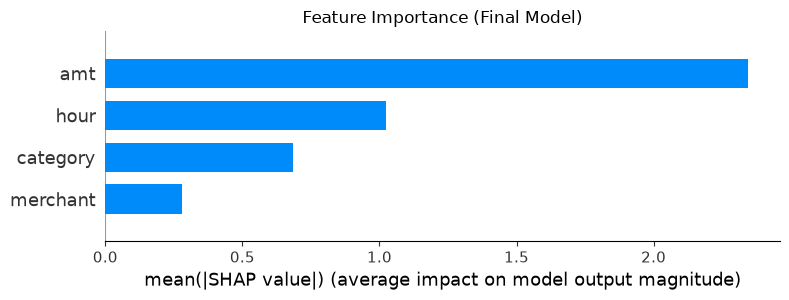

In [7]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:100])

plt.figure(figsize=(8,5))
shap.summary_plot(shap_values, X_test[:100], plot_type="bar", show=False)
plt.title("Feature Importance (Final Model)")
plt.tight_layout()
plt.show()